<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_11/INFO_648_Kmeans_Cluster_Student_Summer26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We will take a look at k-Means clustering (see notes) as a look into unsupervised Machine Learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans #This is new
import plotly.graph_objects as go
from sklearn import preprocessing
import plotly.graph_objects as go
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline


In [2]:
#let's bring in and look at our project data
data=pd.read_csv('student_tracts_raw.csv')

In [3]:
data.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


In [4]:
data.shape

(73057, 49)

In [5]:
#For today we are going to drop the na's - but there are better things for you
#to do for the project
data1=data.dropna()

In [7]:
#With K means, we cannot do categorical data, and there are some columns we should
#not use because they are not relevant or could cause leakage.
#'GISJOIN','STATE','COUNTY','COUNTYA','TRACTA','settlement_type','pop_total_2020'
data2=data1.drop(columns=['GISJOIN','STATE','COUNTY','COUNTYA','TRACTA','settlement_type','pop_total_2020'],axis=1)

No need to train test split - clustering is unsupervised!!!!

In [8]:
data2.head()

,STATEA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_nhother_2010,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2
0,1,1912,693,59,536,157,118,125,138,126,...,1,22,21,0,1,0,13,9,9.809944,194.904273
1,1,2170,743,79,469,274,127,160,183,136,...,3,24,44,3,0,0,24,4,3.340505,649.602380
2,1,3373,1256,70,949,307,243,240,253,158,...,7,63,38,0,2,0,28,19,5.349274,630.552856
3,1,4386,1722,101,1357,365,234,279,272,230,...,1,47,56,2,0,1,21,5,6.382705,687.169468
4,1,10766,4082,226,2459,1623,729,937,977,519,...,12,198,228,19,4,4,78,22,11.397725,944.574466


Because K-Means uses distances, we have to get our data all on the same scale.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), data2.columns.tolist())#lil trick just all the columns
    ]
)

In [10]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('cluster', KMeans(n_clusters=4, random_state=42, n_init=20))
])

pipeline.fit(data2)
#data1['cluster'] = pipeline.named_steps['cluster'].labels_

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['STATEA', 'pop_total_2010',
                                                   'housing_occupied_2010',
                                                   'housing_vacant_2010',
                                                   'housing_owner_occ_2010',
                                                   'housing_renter_occ_2010',
                                                   'age_under5_2010',
                                                   'age_5to9_2010',
                                                   'age_10to14_2010',
                                                   'age_15to17_2010',
                                                   'age_18to19_2010',
                                                   'age_20_2010', 'age_21_2010',
                                                   'age_22to24_2010',
                                                   'age_25to29_2010',
                                                   'age_30to34_2010',
                                                   'age_35to39_2010',
                                                   'age_40to44_2010',
                                                   'age_45to49_2010',
                                                   'age_50to54_2010',
                                                   'age_55to59_2010',
                                                   'age_60to61_2010',
                                                   'age_62to64_2010',
                                                   'age_65to69_2010',
                                                   'age_70to74_2010',
                                                   'age_75to79_2010',
                                                   'age_80to84_2010',
                                                   'age_85plus_2010',
                                                   'race_nhwhite_2010',
                                                   'race_nhblack_2010', ...])])),
                ('cluster', KMeans(n_clusters=4, n_init=20, random_state=42))])

In [11]:
centroids = pipeline.named_steps['cluster'].cluster_centers_

In [12]:
centroids

array([[7.67855563e-01, 8.88199739e-02, 8.07868486e-02, 1.60753533e-02,
        5.16788611e-02, 6.01735097e-02, 4.41457117e-02, 5.91520310e-02,
        6.34327882e-02, 7.52701465e-02, 1.45870595e-02, 1.39712648e-02,
        1.30967399e-02, 1.90845537e-02, 4.93338875e-02, 6.81788194e-02,
        5.96779707e-02, 6.54662523e-02, 9.10545911e-02, 1.08549354e-01,
        7.69926470e-02, 3.44569032e-02, 2.24303250e-02, 1.66081252e-02,
        2.02272810e-02, 3.64189821e-02, 4.90920282e-02, 3.26147853e-02,
        7.61063947e-02, 2.90529834e-02, 3.57293043e-03, 1.14275275e-02,
        7.01510769e-03, 1.90119517e-02, 1.85089418e-02, 1.26303634e-02,
        6.66219502e-03, 4.92793733e-03, 1.99441216e-02, 2.57483449e-02,
        5.12010385e-04, 1.18422434e-02],
       [3.72729225e-01, 8.62278843e-02, 8.01325890e-02, 1.78550711e-02,
        5.51613719e-02, 5.24140837e-02, 4.11938483e-02, 5.61890144e-02,
        6.11760303e-02, 7.31802976e-02, 1.39064406e-02, 1.31126584e-02,
        1.20950486e-02,

In [13]:
scaler = preprocessor.named_transformers_['num'] #find the minmax scaler values

In [14]:
centroids_original = scaler.inverse_transform(centroids) #undo the minmax scaler on the centroids

In [15]:
centroids_original

array([[4.32320560e+01, 3.32648566e+03, 1.29606341e+03, 1.90685841e+02,
        7.97766578e+02, 4.98296834e+02, 2.14327430e+02, 2.08984126e+02,
        2.09581932e+02, 1.32400188e+02, 1.07710847e+02, 5.54519502e+01,
        5.33954084e+01, 1.48191559e+02, 2.35421311e+02, 2.14013314e+02,
        2.08693864e+02, 2.14925706e+02, 2.36559828e+02, 2.38482931e+02,
        2.14347529e+02, 7.79070581e+01, 1.06185158e+02, 1.36236451e+02,
        1.02754587e+02, 8.22340616e+01, 6.56360416e+01, 6.30443800e+01,
        2.17321810e+03, 4.52006316e+02, 3.21099257e+01, 1.19554792e+02,
        6.69241273e+00, 6.23401895e+01, 2.60087650e+02, 1.57374328e+01,
        6.66885722e+00, 1.84304856e+00, 1.67929504e+02, 2.82974311e+01,
        1.13291426e+02, 2.32592562e+03],
       [2.15001074e+01, 3.22940672e+03, 1.28556712e+03, 2.11796853e+02,
        8.51526098e+02, 4.34041027e+02, 1.99996134e+02, 1.98515788e+02,
        2.02125604e+02, 1.28724143e+02, 1.02685157e+02, 5.20441413e+01,
        4.93115133e+01,

In [16]:
centroids_df=pd.DataFrame(centroids_original,columns=data2.columns)

In [17]:
centroids_df

,STATEA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_nhother_2010,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2
0,43.232056,3326.485662,1296.063412,190.685841,797.766578,498.296834,214.327430,208.984126,209.581932,132.400188,...,6.692413,62.340189,260.087650,15.737433,6.668857,1.843049,167.929504,28.297431,113.291426,2325.925615
1,21.500107,3229.406723,1285.567125,211.796853,851.526098,434.041027,199.996134,198.515788,202.125604,128.724143,...,6.157448,57.904307,113.982386,8.413758,3.379014,1.290033,83.093116,16.930888,133.082164,1341.715778
2,8.062324,4889.568582,1772.754981,210.982320,1116.707103,656.047877,326.679253,327.898873,335.256128,210.735579,...,9.937728,110.068687,642.936372,20.388234,16.984823,8.036456,483.577605,73.849953,151.774372,2126.094968
3,39.086715,6681.907464,2468.825007,219.867061,1739.712486,729.112521,451.015466,475.056825,484.287688,296.623773,...,12.357720,114.419150,537.890086,28.419063,12.188809,4.019550,325.689982,56.319750,95.954778,2315.093324


In [19]:
cluster_labels=pipeline.named_steps['cluster'].labels_
cluster_labels
#Let's make a new column and put the cluster number in there
data1['cluster']=cluster_labels

/tmp/ipykernel_9653/3118754245.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['cluster']=cluster_labels


In [20]:
data1.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type,cluster
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,0,1,0,13,9,1775.0,9.809944,194.904273,suburban,2
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,3,0,0,24,4,2055.0,3.340505,649.602380,suburban,2
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,0,2,0,28,19,3216.0,5.349274,630.552856,suburban,2
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,2,0,1,21,5,4246.0,6.382705,687.169468,suburban,2
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,19,4,4,78,22,11222.0,11.397725,944.574466,suburban,2


In [21]:
#How balanced are our clusters??
data1.groupby('cluster').size()

,0
cluster,
0,23415
1,18617
2,19191
3,11516


In [23]:
import plotly.express as px

# Find the dominant cluster for each state using data1
cluster_state_counts = data1.groupby(['STATE', 'cluster']).size().unstack(fill_value=0)
cluster_state_counts['Dominant_Cluster'] = cluster_state_counts.idxmax(axis=1)
cluster_state_counts = cluster_state_counts.reset_index()

# Rename the cluster count columns to strings for plotly.express
cluster_state_counts = cluster_state_counts.rename(columns={
    0: 'Cluster 0 Count',
    1: 'Cluster 1 Count',
    2: 'Cluster 2 Count',
    3: 'Cluster 3 Count'
})

# Load state abbreviation data for merging
state_abbr = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/2014_usa_states.csv")

# Merge with state abbreviations to get 'Postal' codes for plotting
cluster_map_data = pd.merge(cluster_state_counts, state_abbr, how='left', left_on='STATE', right_on='State')

# Create the choropleth map colored by Dominant Cluster
fig = px.choropleth(
    cluster_map_data,
    locations='Postal',
    locationmode="USA-states",
    color='Dominant_Cluster', # Color states by their dominant cluster
    scope="usa",
    hover_name='STATE',
    hover_data={
        'Postal': False, # Hide Postal code in hover
        'Dominant_Cluster': True, # Show dominant cluster
        'Cluster 0 Count': True, # Show count for Cluster 0
        'Cluster 1 Count': True, # Show count for Cluster 1
        'Cluster 2 Count': True, # Show count for Cluster 2
        'Cluster 3 Count': True  # Show count for Cluster 3
    },
    labels={
        'Dominant_Cluster': 'Dominant Cluster',
        'Cluster 0 Count': 'Cluster 0 Count',
        'Cluster 1 Count': 'Cluster 1 Count',
        'Cluster 2 Count': 'Cluster 2 Count',
        'Cluster 3 Count': 'Cluster 3 Count'
    },
    title="Dominant K-Means Cluster by State"
)

fig.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)', lakecolor='rgb(255, 255, 255)'))
fig.show()

<Axes: xlabel='cluster', ylabel='pop_total_2010'>

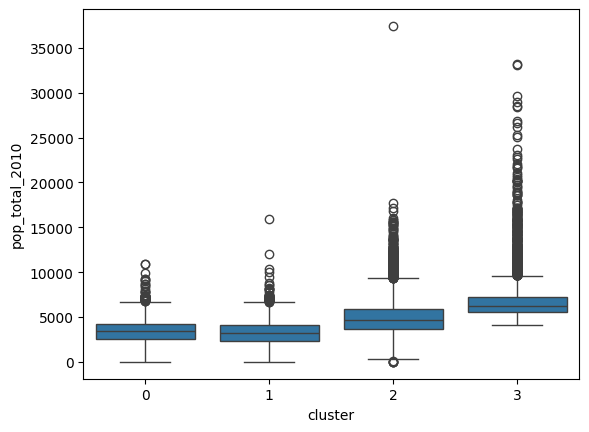

In [24]:
import seaborn as sns
sns.boxplot(x='cluster',y='pop_total_2010',data=data1)

We need to determine how many clusters we should use - a good way to start is plotting the distortion for each value of k and then looking for the elbow (distortion is the sum of the squared differences (Euclidean distances) between each data point and the centroid of its assigned cluster.)

In [25]:
distortions = []

for i in range(1, 11):

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('cluster', KMeans(n_clusters=i, random_state=0, n_init=10))
    ])

    pipeline.fit(data1)

    distortions.append(
        pipeline.named_steps['cluster'].inertia_
    )

    print(f"clusters {i} {pipeline.named_steps['cluster'].inertia_}")

clusters 1 11026.61770826236
clusters 2 6395.983808166554
clusters 3 5581.516096103597
clusters 4 4861.23970439382
clusters 5 4360.753539463332
clusters 6 4089.3194564576424
clusters 7 3866.8868650366007
clusters 8 3655.414590893454
clusters 9 3496.593699323786
clusters 10 3357.298478039187


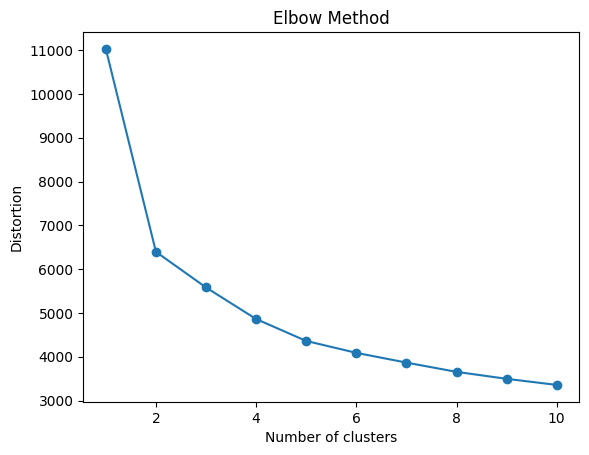

In [26]:
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method')
plt.show()